#### ============================================
#### CHANAKYA - AI Commerce Intelligence Platform
#### Layer 5: RFM + Customer Segmentation
#### Author: Devesh Shukla
#### ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize']     = (12, 6)
plt.rcParams['font.size']          = 11
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_palette('Set2')

# Paths
PROCESSED_PATH = r'C:\Users\Dell\CHANAKYA\data\processed'
RFM_PATH       = r'C:\Users\Dell\CHANAKYA\layer5_rfm_segmentation'

# Load data
df_orders      = pd.read_csv(f'{PROCESSED_PATH}/orders_processed.csv')
df_order_items = pd.read_csv(f'{PROCESSED_PATH}/order_items_processed.csv')
df_customers   = pd.read_csv(f'{PROCESSED_PATH}/customers_processed.csv')

# Parse dates
df_orders['order_date']      = pd.to_datetime(df_orders['order_date'],      format='mixed')
df_order_items['order_date'] = pd.to_datetime(df_order_items['order_date'], format='mixed')

# Only delivered orders
delivered = df_order_items[df_order_items['order_status'] == 'Delivered']

print("=" * 55)
print("   CHANAKYA — LAYER 5: RFM + SEGMENTATION")
print("=" * 55)
print(f"\nData loaded successfully!")
print(f"  Orders      : {len(df_orders):,}")
print(f"  Order Items : {len(df_order_items):,}")
print(f"  Customers   : {len(df_customers):,}")
print(f"  Delivered   : {len(delivered):,} line items")
print(f"\nRFM Analysis started!")

   CHANAKYA — LAYER 5: RFM + SEGMENTATION

Data loaded successfully!
  Orders      : 5,010
  Order Items : 8,769
  Customers   : 1,000
  Delivered   : 6,108 line items

RFM Analysis started!


#### ============================================
#### RFM CALCULATION
#### Recency, Frequency, Monetary
#### ============================================

In [2]:
print("=" * 55)
print("   RFM CALCULATION")
print("=" * 55)

# Reference date — analysis date
reference_date = datetime(2026, 3, 18)

# Merge orders with customers
df_merged = delivered.merge(
    df_orders[['order_id', 'order_date', 'customer_id']],
    on=['order_id', 'customer_id'], how='left'
)
df_merged['order_date'] = pd.to_datetime(df_merged['order_date_y'], format='mixed')

# RFM Calculation
rfm = df_merged.groupby('customer_id').agg(
    recency   = ('order_date',  lambda x: (reference_date - x.max()).days),
    frequency = ('order_id',    'nunique'),
    monetary  = ('revenue',     'sum')
).reset_index()

rfm['monetary'] = rfm['monetary'].round(2)

print(f"\nRFM Table created!")
print(f"  Total Customers analyzed : {len(rfm):,}")
print(f"\nRFM Statistics:")
print(f"  {'Metric':<12} {'Min':>10} {'Max':>10} {'Mean':>10} {'Median':>10}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"  {'Recency':<12} {rfm['recency'].min():>10} {rfm['recency'].max():>10} {rfm['recency'].mean():>10.1f} {rfm['recency'].median():>10.1f}")
print(f"  {'Frequency':<12} {rfm['frequency'].min():>10} {rfm['frequency'].max():>10} {rfm['frequency'].mean():>10.1f} {rfm['frequency'].median():>10.1f}")
print(f"  {'Monetary':<12} {rfm['monetary'].min():>10.0f} {rfm['monetary'].max():>10.0f} {rfm['monetary'].mean():>10.0f} {rfm['monetary'].median():>10.0f}")

print(f"\nSample RFM Table (Top 5):")
print(f"  {'Customer':<12} {'Recency':>10} {'Frequency':>10} {'Monetary':>12}")
print(f"  {'-'*12} {'-'*10} {'-'*10} {'-'*12}")
for _, row in rfm.nlargest(5, 'monetary').iterrows():
    print(f"  {row['customer_id']:<12} {row['recency']:>10} {row['frequency']:>10} Rs.{row['monetary']:>9,.0f}")

   RFM CALCULATION

RFM Table created!
  Total Customers analyzed : 971

RFM Statistics:
  Metric              Min        Max       Mean     Median
  ------------ ---------- ---------- ---------- ----------
  Recency              -1       1145      298.5      220.0
  Frequency             1         11        3.6        3.0
  Monetary            179     302404      27512      12878

Sample RFM Table (Top 5):
  Customer        Recency  Frequency     Monetary
  ------------ ---------- ---------- ------------
  CUST0559             95          8 Rs.  302,404
  CUST0227            482          4 Rs.  269,467
  CUST0493            115          6 Rs.  224,323
  CUST0691            129          5 Rs.  196,097
  CUST0324             89          6 Rs.  192,641


#### ============================================
#### RFM SCORING — 1 to 5 Scale
#### ============================================

In [3]:
print("=" * 55)
print("   RFM SCORING")
print("=" * 55)

# Fix negative recency
rfm['recency'] = rfm['recency'].clip(lower=0)

# RFM Scores — 1 to 5
# Recency  — lower is better (recent customer)
# Frequency — higher is better
# Monetary  — higher is better

rfm['R_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                           q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM Score
rfm['RFM_score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)

rfm['Total_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(f"\nRFM Scores assigned!")
print(f"\nScore Distribution:")
print(f"  {'Score':<12} {'Min':>6} {'Max':>6} {'Mean':>6}")
print(f"  {'-'*12} {'-'*6} {'-'*6} {'-'*6}")
print(f"  {'R_score':<12} {rfm['R_score'].min():>6} {rfm['R_score'].max():>6} {rfm['R_score'].mean():>6.1f}")
print(f"  {'F_score':<12} {rfm['F_score'].min():>6} {rfm['F_score'].max():>6} {rfm['F_score'].mean():>6.1f}")
print(f"  {'M_score':<12} {rfm['M_score'].min():>6} {rfm['M_score'].max():>6} {rfm['M_score'].mean():>6.1f}")
print(f"  {'Total':<12} {rfm['Total_score'].min():>6} {rfm['Total_score'].max():>6} {rfm['Total_score'].mean():>6.1f}")

print(f"\nSample Scored Customers:")
print(f"  {'Customer':<12} {'R':>4} {'F':>4} {'M':>4} {'RFM':>6} {'Total':>6}")
print(f"  {'-'*12} {'-'*4} {'-'*4} {'-'*4} {'-'*6} {'-'*6}")
for _, row in rfm.nlargest(8, 'Total_score').iterrows():
    print(f"  {row['customer_id']:<12} {row['R_score']:>4} {row['F_score']:>4} {row['M_score']:>4} {row['RFM_score']:>6} {row['Total_score']:>6}")

   RFM SCORING

RFM Scores assigned!

Score Distribution:
  Score           Min    Max   Mean
  ------------ ------ ------ ------
  R_score           1      5    3.0
  F_score           1      5    3.0
  M_score           1      5    3.0
  Total             3     15    9.0

Sample Scored Customers:
  Customer        R    F    M    RFM  Total
  ------------ ---- ---- ---- ------ ------
  CUST0022        5    5    5    555     15
  CUST0185        5    5    5    555     15
  CUST0324        5    5    5    555     15
  CUST0325        5    5    5    555     15
  CUST0326        5    5    5    555     15
  CUST0350        5    5    5    555     15
  CUST0374        5    5    5    555     15
  CUST0387        5    5    5    555     15


#### ============================================
#### CUSTOMER SEGMENTATION
#### ============================================

In [4]:
print("=" * 55)
print("   CUSTOMER SEGMENTATION")
print("=" * 55)

def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    t = row['Total_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 3 and m <= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'New Customers'
    elif t >= 9:
        return 'Promising'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Segment Summary
seg_summary = rfm.groupby('segment').agg(
    customers     = ('customer_id', 'count'),
    avg_recency   = ('recency',     'mean'),
    avg_frequency = ('frequency',   'mean'),
    avg_monetary  = ('monetary',    'mean'),
    total_revenue = ('monetary',    'sum')
).round(1).sort_values('total_revenue', ascending=False).reset_index()

print(f"\nCustomer Segments Created!")
print(f"\n{'Segment':<22} {'Customers':>10} {'Avg Recency':>12} {'Avg Freq':>9} {'Avg Spend':>12} {'Total Rev':>14}")
print(f"  {'-'*22} {'-'*10} {'-'*12} {'-'*9} {'-'*12} {'-'*14}")
for _, row in seg_summary.iterrows():
    print(f"  {row['segment']:<22} {int(row['customers']):>10,} {row['avg_recency']:>12.0f} "
          f"{row['avg_frequency']:>9.1f} Rs.{row['avg_monetary']:>8,.0f} "
          f"Rs.{row['total_revenue']:>10,.0f}")

# Save RFM table
rfm.to_csv(f'{RFM_PATH}/rfm_segments.csv', index=False)
print(f"\nRFM segments saved: rfm_segments.csv")

   CUSTOMER SEGMENTATION

Customer Segments Created!

Segment                 Customers  Avg Recency  Avg Freq    Avg Spend      Total Rev
  ---------------------- ---------- ------------ --------- ------------ --------------
  Champions                     129          116       5.8 Rs.  64,616 Rs. 8,335,504
  At Risk                       119          453       4.4 Rs.  45,805 Rs. 5,450,758
  Loyal Customers               100          193       4.7 Rs.  52,698 Rs. 5,269,814
  Needs Attention               132          471       2.7 Rs.  22,296 Rs. 2,943,144
  Potential Loyalists           185          151       4.4 Rs.   9,898 Rs. 1,831,137
  Recent Customers              105          119       2.3 Rs.  14,142 Rs. 1,484,956
  Promising                      16          226       2.6 Rs.  49,649 Rs.   794,391
  Lost Customers                155          573       1.7 Rs.   3,283 Rs.   508,926
  New Customers                  30          225       1.7 Rs.   3,171 Rs.    95,134

RFM segm

#### ============================================
#### RFM VISUALIZATION
#### ============================================

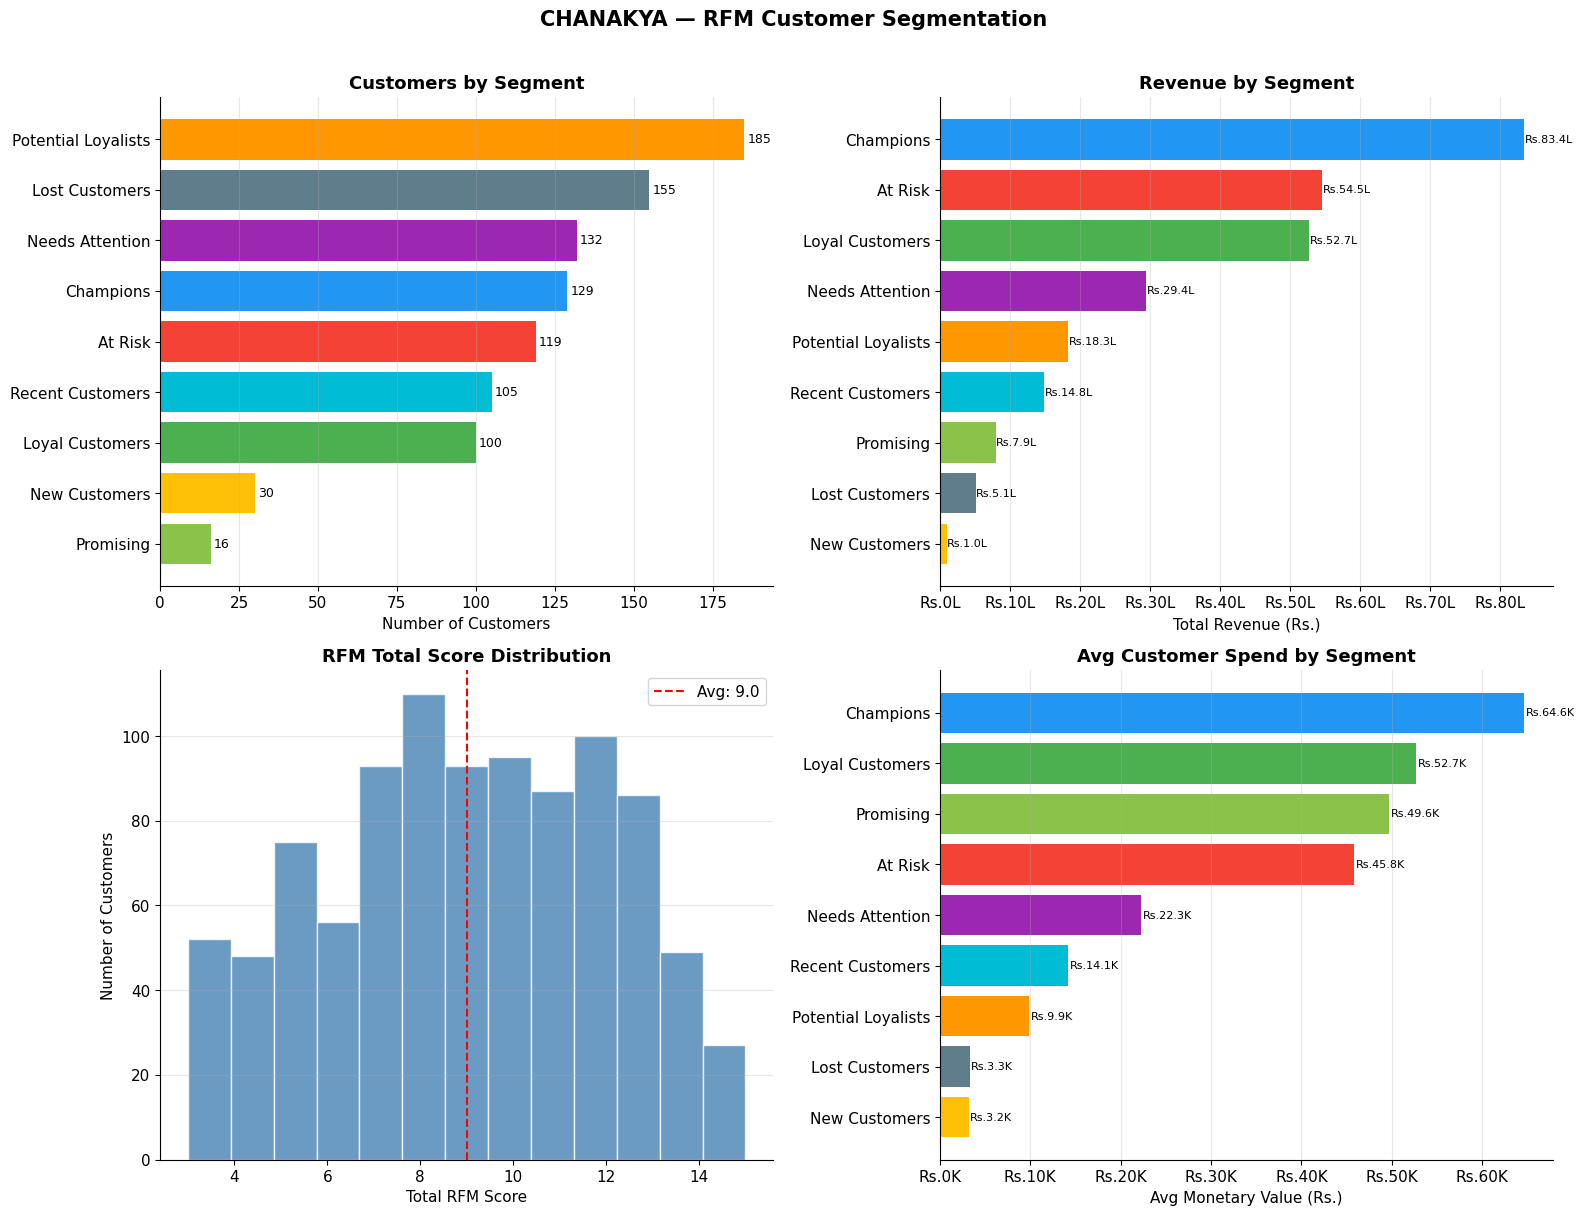

Chart saved: 05_rfm_segmentation.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color map for segments
seg_colors = {
    'Champions'          : '#2196F3',
    'Loyal Customers'    : '#4CAF50',
    'At Risk'            : '#F44336',
    'Potential Loyalists': '#FF9800',
    'Needs Attention'    : '#9C27B0',
    'Recent Customers'   : '#00BCD4',
    'Promising'          : '#8BC34A',
    'Lost Customers'     : '#607D8B',
    'New Customers'      : '#FFC107',
}

# Plot 1 — Customers by Segment
seg_counts = rfm['segment'].value_counts()
colors_seg = [seg_colors.get(s, '#999999') for s in seg_counts.index]
axes[0,0].barh(seg_counts.index[::-1], seg_counts.values[::-1], color=colors_seg[::-1])
axes[0,0].set_title('Customers by Segment', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Number of Customers')
for i, val in enumerate(seg_counts.values[::-1]):
    axes[0,0].text(val + 1, i, str(val), va='center', fontsize=9)
axes[0,0].grid(axis='x', alpha=0.3)

# Plot 2 — Revenue by Segment
seg_rev = seg_summary.sort_values('total_revenue', ascending=True)
colors_rev = [seg_colors.get(s, '#999999') for s in seg_rev['segment']]
axes[0,1].barh(seg_rev['segment'], seg_rev['total_revenue'], color=colors_rev)
axes[0,1].set_title('Revenue by Segment', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Total Revenue (Rs.)')
axes[0,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.0f}L'))
for i, val in enumerate(seg_rev['total_revenue']):
    axes[0,1].text(val + 10000, i, f'Rs.{val/100000:.1f}L', va='center', fontsize=8)
axes[0,1].grid(axis='x', alpha=0.3)

# Plot 3 — RFM Score Distribution
axes[1,0].hist(rfm['Total_score'], bins=13, color='steelblue',
               edgecolor='white', alpha=0.8)
axes[1,0].set_title('RFM Total Score Distribution', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Total RFM Score')
axes[1,0].set_ylabel('Number of Customers')
axes[1,0].axvline(rfm['Total_score'].mean(), color='red', linestyle='--',
                   linewidth=1.5, label=f"Avg: {rfm['Total_score'].mean():.1f}")
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Plot 4 — Avg Monetary by Segment
seg_mon = seg_summary.sort_values('avg_monetary', ascending=True)
colors_mon = [seg_colors.get(s, '#999999') for s in seg_mon['segment']]
axes[1,1].barh(seg_mon['segment'], seg_mon['avg_monetary'], color=colors_mon)
axes[1,1].set_title('Avg Customer Spend by Segment', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Avg Monetary Value (Rs.)')
axes[1,1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x/1000:.0f}K'))
for i, val in enumerate(seg_mon['avg_monetary']):
    axes[1,1].text(val + 200, i, f'Rs.{val/1000:.1f}K', va='center', fontsize=8)
axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle('CHANAKYA — RFM Customer Segmentation', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RFM_PATH}/05_rfm_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: 05_rfm_segmentation.png")

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.ticker as mticker
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

seg_data = [
    ('Lost Customers',       508926,  '#607D8B', 155),
    ('New Customers',         95134,  '#FFC107',  30),
    ('Promising',            794391,  '#8BC34A',  16),
    ('Recent Customers',    1484956,  '#00BCD4', 105),
    ('Potential Loyalists', 1831137,  '#FF9800', 185),
    ('Needs Attention',     2943144,  '#9C27B0', 132),
    ('Loyal Customers',     5269814,  '#4CAF50', 100),
    ('At Risk',             5450758,  '#F44336', 119),
    ('Champions',           8335504,  '#2196F3', 129),
]

names    = [s[0] for s in seg_data]
revenues = [s[1] for s in seg_data]
colors   = [s[2] for s in seg_data]
counts   = [s[3] for s in seg_data]
max_rev  = max(revenues)
FRAMES   = 80

def animate(frame):
    ax.clear()
    ax.set_facecolor('#0D1117')
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')

    progress = frame / FRAMES
    current_revenues = []
    for i, rev in enumerate(revenues):
        delay    = i / len(revenues) * 0.6
        seg_prog = max(0, min((progress - delay) / 0.5, 1.0))
        seg_prog = 1 - (1 - seg_prog) ** 3
        current_revenues.append(rev * seg_prog)

    bars = ax.barh(names, current_revenues, color=colors,
                   edgecolor='#222', height=0.6)

    for i, (bar, rev, count) in enumerate(zip(bars, current_revenues, counts)):
        if rev > max_rev * 0.05:
            ax.text(rev + max_rev * 0.01,
                    bar.get_y() + bar.get_height()/2,
                    f'Rs.{rev/100000:.1f}L | {count} customers',
                    va='center', ha='left', fontsize=9,
                    color='white', fontweight='bold')

    ax.set_xlim(0, max_rev * 1.4)
    ax.set_xlabel('Total Revenue (Rs.)', color='white', fontsize=11)
    ax.set_title('CHANAKYA — Revenue by Customer Segment',
                 color='white', fontsize=14, fontweight='bold', pad=15)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rs.{x/100000:.0f}L'))

    # Progress indicator
    ax.text(0.99, 0.02, f'{int(progress*100)}%',
            transform=ax.transAxes,
            color='#2196F3', fontsize=12,
            fontweight='bold', ha='right')

    return bars

ani = animation.FuncAnimation(
    fig, animate,
    frames     = FRAMES,
    interval   = 50,
    repeat     = False
)


plt.close()
HTML(ani.to_jshtml())

#### ============================================
#### LAYER 5 — RFM COMPLETE SUMMARY
#### ============================================

In [14]:
print("=" * 55)
print("   CHANAKYA — LAYER 5 COMPLETE!")
print("   RFM + Customer Segmentation")
print("=" * 55)

print("\nRFM ANALYSIS SUMMARY:")
print("-" * 55)
print(f"  Total Customers Analyzed : {len(rfm):,}")
print(f"  Total Segments Created   : {rfm['segment'].nunique()}")
print(f"  Reference Date           : 18-March-2026")

print("\nSEGMENT BREAKDOWN:")
print("-" * 55)
print(f"  {'Segment':<22} {'Customers':>10} {'Revenue':>14} {'Priority'}")
print(f"  {'-'*22} {'-'*10} {'-'*14} {'-'*10}")

priority_map = {
    'Champions'          : 'RETAIN',
    'Loyal Customers'    : 'REWARD',
    'At Risk'            : 'WIN BACK',
    'Potential Loyalists': 'UPSELL',
    'Needs Attention'    : 'ENGAGE',
    'Recent Customers'   : 'NURTURE',
    'Promising'          : 'GROW',
    'Lost Customers'     : 'REACTIVATE',
    'New Customers'      : 'ONBOARD',
}

for _, row in seg_summary.iterrows():
    priority = priority_map.get(row['segment'], '')
    rev = f"Rs.{row['total_revenue']/100000:.1f}L"
    print(f"  {row['segment']:<22} {int(row['customers']):>10,} {rev:>14} {priority}")

print("\nKEY BUSINESS RECOMMENDATIONS:")
print("-" * 55)
print(f"  1. Champions (129)      — Exclusive loyalty rewards")
print(f"  2. At Risk (119)        — Urgent win-back campaigns")
print(f"  3. Loyal (100)          — Premium membership offers")
print(f"  4. Pot. Loyalists (185) — Targeted upsell strategy")
print(f"  5. Lost (155)           — Re-engagement discounts")

print("\nFILES SAVED:")
print("-" * 55)
print(f"  rfm_segments.csv        — RFM data with segments")
print(f"  rfm_bar_animated.gif    — Animated visualization")

print("\nINTERVIEW READY — KEY POINTS:")
print("-" * 55)
print(f"  1. RFM — Recency, Frequency, Monetary analysis")
print(f"  2. Quintile scoring — 1 to 5 scale per metric")
print(f"  3. 9 business segments with action strategies")
print(f"  4. Pareto — Top 13% customers = 31% revenue")
print(f"  5. Animated visualization for LinkedIn showcase")

print("\nDATA READY FOR:")
print(f"  Layer 6 — Anomaly Detection")
print(f"  Layer 7 — ML Demand Forecasting")

print("\n" + "=" * 55)
print("   LAYER 5 COMPLETE — RFM Segmentation Done!")
print("=" * 55)

   CHANAKYA — LAYER 5 COMPLETE!
   RFM + Customer Segmentation

RFM ANALYSIS SUMMARY:
-------------------------------------------------------
  Total Customers Analyzed : 971
  Total Segments Created   : 9
  Reference Date           : 18-March-2026

SEGMENT BREAKDOWN:
-------------------------------------------------------
  Segment                 Customers        Revenue Priority
  ---------------------- ---------- -------------- ----------
  Champions                     129       Rs.83.4L RETAIN
  At Risk                       119       Rs.54.5L WIN BACK
  Loyal Customers               100       Rs.52.7L REWARD
  Needs Attention               132       Rs.29.4L ENGAGE
  Potential Loyalists           185       Rs.18.3L UPSELL
  Recent Customers              105       Rs.14.8L NURTURE
  Promising                      16        Rs.7.9L GROW
  Lost Customers                155        Rs.5.1L REACTIVATE
  New Customers                  30        Rs.1.0L ONBOARD

KEY BUSINESS RECOMMENDAT